In [1]:
#1. Imports
#--------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from bert_score import score as bert_score
import os
import time
from tqdm import tqdm

In [2]:
#2. Load evaluation sample
df = pd.read_csv("../data/sample_bitext.csv")
print(f"Loaded {len(df)} evaluation samples")
print(f"Columns: {list(df.columns)}")

Loaded 110 evaluation samples
Columns: ['flags', 'instruction', 'category', 'intent', 'response']


In [3]:
#3. Load FLan-T5-base model 
MODEL_NAME = "google/flan-t5-base"
MAX_NEW_TOKENS = 150 

print(f"Loading model: {MODEL_NAME}")
print("(First load downloads ~990MB. Subsequent loads use cache.)")

text_generator = pipeline(
    task="text2text-generation",   # Flan-T5 is a text-to-text model
    model=MODEL_NAME,
    max_new_tokens=MAX_NEW_TOKENS,
    do_sample=False,               
)

print(f"\n {MODEL_NAME}Model loaded successfully: ")


Loading model: google/flan-t5-base
(First load downloads ~990MB. Subsequent loads use cache.)


d:\zeerasdev\customer-support-llm-evaluator\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



 google/flan-t5-baseModel loaded successfully: 


In [4]:
# Quick sanity check
test_response = text_generator("How do I reset my password?")
print(f"\nSanity check response: {test_response[0]['generated_text']}")



Sanity check response: Click on the "Reset Password" button and enter your password.


In [5]:
#4. Use the Prompt
#--------------------------------------
import sys
sys.path.append("..") #for src folder imports

from src.prompts import build_customer_support_prompt

# Test the template
sample_instruction = df["instruction"].iloc[0]
sample_prompt = build_customer_support_prompt(sample_instruction)
print("Example prompt:")
print(sample_prompt)

Example prompt:
You are a professional customer support agent. Answer the following customer question clearly and helpfully.

Customer: where to notify of problems with sign-up?

Agent:


In [6]:
#5. Generate Model Responses
#--------------------------------------
def generate_responses(
    generator_pipeline,
    instructions: list,
    batch_size: int = 8
) -> list:
    
    responses = []
    prompts = [build_customer_support_prompt(inst) for inst in instructions]

    print(f"Generating responses for {len(prompts)} prompts...")
    print(f"Estimated time: {len(prompts) * 3 / 60:.1f} minutes on CPU")

    for i in tqdm(range(0, len(prompts), batch_size), desc="Generating"):
        batch = prompts[i : i + batch_size]
        batch_outputs = generator_pipeline(batch)
        #batch_texts = [output[0]["generated_text"] for output in batch_outputs] #keyError 0
        batch_texts = [output["generated_text"] for output in batch_outputs]
        responses.extend(batch_texts)

    return responses


generated_responses = generate_responses(
    generator_pipeline=text_generator,
    instructions=df["instruction"].tolist()
)

# Add to DataFrame
df["generated_response"] = generated_responses

print(f"\nGeneration complete. {len(generated_responses)} responses generated.")
print(f"\nExample:")
print(f"  Instruction : {df['instruction'].iloc[0]}")
print(f"  Reference   : {df['response'].iloc[0]}")
print(f"  Generated   : {df['generated_response'].iloc[0]}")

Generating responses for 110 prompts...
Estimated time: 5.5 minutes on CPU


Generating: 100%|██████████| 14/14 [01:24<00:00,  6.02s/it]


Generation complete. 110 responses generated.

Example:
  Instruction : where to notify of problems with sign-up?
  Reference   : Glad you contacted to us regarding the problems you encountered during the sign-up process. We value your feedback and want to ensure a smooth experience for all our users. To notify us of any sign-up issues or problems, we recommend contacting our customer support team. They are available {{Customer Support Hours}} at {{Customer Support Phone Number}} or through the Live Chat on our website at {{Website URL}}. Our dedicated support agents will be more than happy to assist you and gather all the necessary information to address the problem effectively. Rest assured, we take all sign-up issues seriously and are committed to resolving them promptly. We appreciate your patience and understanding as we work towards improving our sign-up process.
  Generated   : the "My Account" page


In [7]:
#6. Score Faithfullness using BERTScore
#--------------------------------------
FAITHFULNESS_THRESHOLD = 0.75 
BERTSCORE_MODEL = "distilbert-base-uncased"

print("Computing BERTScore faithfulness scores...")
print(f"Using embedding model: {BERTSCORE_MODEL}")
print(f"This may take 5–10 minutes on CPU...")

precision_scores, recall_scores, f1_scores = bert_score(
    cands=df["generated_response"].tolist(),   # What the model generated
    refs=df["response"].tolist(),               # Ground truth reference answers
    model_type=BERTSCORE_MODEL,
    verbose=True
)

# Convert PyTorch tensors to numpy for pandas
df["faithfulness_precision"] = precision_scores.numpy()
df["faithfulness_recall"]    = recall_scores.numpy()
df["faithfulness_f1"]        = f1_scores.numpy()

# Flag responses below threshold
df["faithfulness_pass"] = df["faithfulness_f1"] >= FAITHFULNESS_THRESHOLD

print(f"\nFaithfulness scoring complete")
print(f"Mean F1 score  : {df['faithfulness_f1'].mean():.4f}")
print(f"Pass rate      : {df['faithfulness_pass'].mean() * 100:.1f}%")
print(f"Failed samples : {(~df['faithfulness_pass']).sum()}")


Computing BERTScore faithfulness scores...
Using embedding model: distilbert-base-uncased
This may take 5–10 minutes on CPU...


d:\zeerasdev\customer-support-llm-evaluator\.venv\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


calculating scores...
computing bert embedding.


  0%|          | 0/3 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/2 [00:00<?, ?it/s]

done in 34.90 seconds, 3.15 sentences/sec

Faithfulness scoring complete
Mean F1 score  : 0.6566
Pass rate      : 9.1%
Failed samples : 100


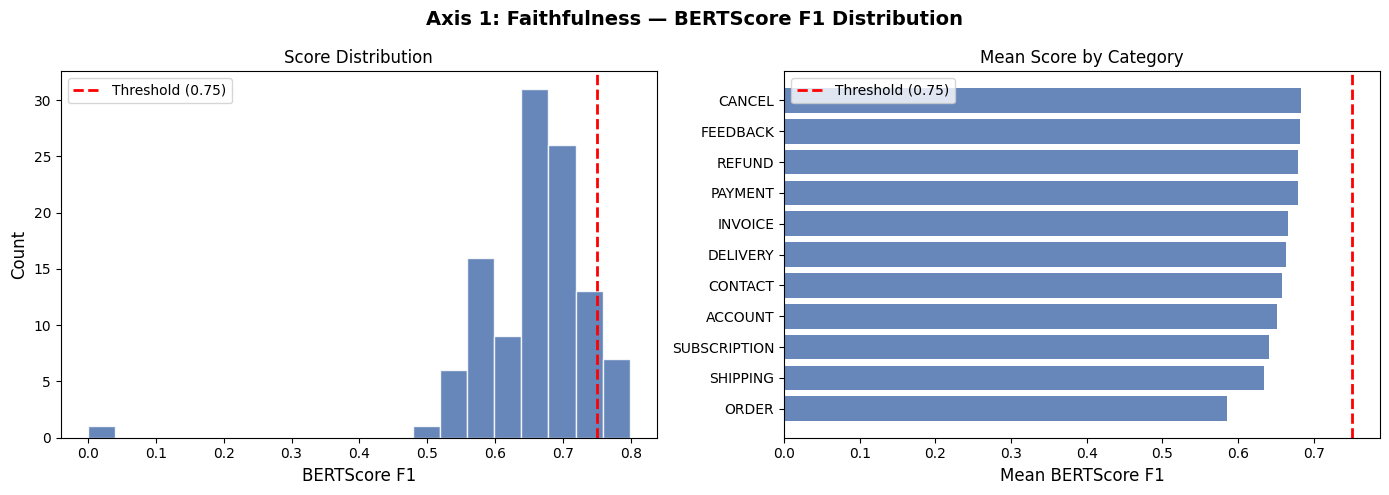

Plot saved to: ../outputs/plots/faithfulness_distribution.png


In [8]:
#7. Visualize Results
#--------------------------------------
def plot_faithfulness_distribution(
    dataframe: pd.DataFrame,
    output_path: str
) -> None:
   
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Axis 1: Faithfulness — BERTScore F1 Distribution", fontsize=14, fontweight="bold")

    # Left: Histogram of all F1 scores
    axes[0].hist(dataframe["faithfulness_f1"], bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
    axes[0].axvline(x=FAITHFULNESS_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Threshold ({FAITHFULNESS_THRESHOLD})")
    axes[0].set_xlabel("BERTScore F1", fontsize=12)
    axes[0].set_ylabel("Count", fontsize=12)
    axes[0].set_title("Score Distribution")
    axes[0].legend()

    # Right: Box plot by category
    category_means = dataframe.groupby("category")["faithfulness_f1"].mean().sort_values()
    axes[1].barh(category_means.index, category_means.values, color="#4C72B0", alpha=0.85)
    axes[1].axvline(x=FAITHFULNESS_THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Threshold ({FAITHFULNESS_THRESHOLD})")
    axes[1].set_xlabel("Mean BERTScore F1", fontsize=12)
    axes[1].set_title("Mean Score by Category")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved to: {output_path}")


plot_faithfulness_distribution(
    dataframe=df,
    output_path="../outputs/plots/faithfulness_distribution.png"
)


In [9]:
#8. Save Results
#--------------------------------------
faithfulness_output_path = "../outputs/faithfulness_scores.csv"

df[[
    "instruction", "response", "generated_response",
    "category", "intent",
    "faithfulness_precision", "faithfulness_recall", "faithfulness_f1",
    "faithfulness_pass"
]].to_csv(faithfulness_output_path, index=False)

print(f"Results saved to: {faithfulness_output_path}")
print(f"\n=== Faithfulness Axis Summary ===")
print(f"Total evaluated : {len(df)}")
print(f"Mean F1 score   : {df['faithfulness_f1'].mean():.4f}")
print(f"Min F1 score    : {df['faithfulness_f1'].min():.4f}")
print(f"Max F1 score    : {df['faithfulness_f1'].max():.4f}")
print(f"Pass rate (≥{FAITHFULNESS_THRESHOLD}) : {df['faithfulness_pass'].mean()*100:.1f}%")

# Show worst performers
print(f"\nBottom 5 faithfulness scores:")
worst = df.nsmallest(5, "faithfulness_f1")[["instruction", "faithfulness_f1", "generated_response"]]
for _, row in worst.iterrows():
    print(f"  Score {row['faithfulness_f1']:.3f}: {row['instruction'][:60]}...")


Results saved to: ../outputs/faithfulness_scores.csv

=== Faithfulness Axis Summary ===
Total evaluated : 110
Mean F1 score   : 0.6566
Min F1 score    : 0.0000
Max F1 score    : 0.7984
Pass rate (≥0.75) : 9.1%

Bottom 5 faithfulness scores:
  Score 0.000: I need assistancde cancelling order {{Order Number}}...
  Score 0.501: wanna see what hours cdustomer support available is...
  Score 0.522: I need to set a damn shipping address up, will you help me?...
  Score 0.528: watn assistance removing a standard account...
  Score 0.532: can you help me remove something from purchase {{Order Numbe...
